# SQL 04 — The semantic model: measures, a star schema, and one readable chart

**Time:** about 2 hours. Roughly 45 minutes of demonstration, the rest is you.

## 📚 Learning objectives

By the end of this notebook you can:

- Say the **grain** of a table in one sentence — *"one row is one ..."* — and explain why every
  other decision depends on it.
- Explain the difference between a **column** and a **measure**, and show a case where averaging
  a column gives a different answer from evaluating the measure.
- Build a **star schema** from a flat table: a thin **fact** table of keys, wide **dimension**
  tables of attributes; and test that each dimension's key really determines its attributes.
- Write measures **once**, in a registry, and re-use them across any grouping — the difference
  between a **self-serve model** and a dashboard built on request.
- Show that one metric name can carry three defensible definitions, and say what has to be
  written down so that a reader can tell which one they are looking at.
- Build a chart a person can read **when you are not in the room to explain it**.

## Why this notebook exists

The market pass behind this `SQL/` folder read 322 real job postings, 183 of them located in
Saudi Arabia. Alongside SQL, it found a second cluster:

| named in the 183 Saudi postings | count | share |
|---|---|---|
| a BI tool of any kind | 47 | 26% |
| Power BI or Microsoft Fabric by name | 41 | 22% |
| the word "dashboard" | 60 | 33% |
| Excel or MS Office | 38 | 21% |

Against that, a term-by-term scan of the 427 notebooks this diploma contained before this folder
existed found **no dashboard built anywhere**, **zero** occurrences of "Tableau", "Streamlit",
"star schema", "semantic model" or "fact table", and "Power BI" in exactly one passing sentence.

**This notebook does not teach Power BI.** Power BI Desktop runs only on Windows and cannot run
inside a notebook, so teaching the tool would break this repository's portability rule and half a
class could not follow along. It teaches the half that survives a change of tool — grain, keys,
star schemas, measures, additivity, and one metric with one definition — using SQLite and
matplotlib, which run everywhere. Part 7 then says plainly what Power BI and the PL-300 exam are,
what the exam costs in Saudi Arabia, and what it covers.

## 🔗 Where this fits

**Assumes** lessons 01 and 02 of this folder: `SELECT ... WHERE ... GROUP BY ... HAVING`,
`INNER` and `LEFT JOIN`, fan-out, and CTEs. Lesson 03 is not required, but its habit — prove a
number wrong before you theorise about why — is used throughout.

**Comes after** the whole of Course 04, where you learned to load a CSV into pandas and describe
it. A DataFrame is a value you built and can see. A model is a contract several people will use
without asking you.

**Why it is not inside one of the twelve official courses.** It is not in the TVTC specification
for this programme, and neither is SQL. `SQL/README.md` records the market evidence for adding
the strand and the hours it is taken from. Filing this lesson under a course would mean claiming
it implements a learning outcome the specification does not contain.

**Feeds into:** your final project, and the first analyst job most of you will hold — where the
question is almost never "can you build a model" and almost always "why does your number differ
from the one in last month's deck".

## Part 0 — Set up

Two cells. The first finds the repository and imports the shared data loader; the second builds
the flat table you already know from lessons 01–03.

Everything here runs on Python's built-in **`sqlite3`**. Nothing to install, no server, no
account, and no network once the data file is on your disk. It behaves the same on Windows, macOS
and Google Colab.

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHY not a relative path: '../../Course 04/datasets/...' only resolves when the kernel's
# working directory happens to be this notebook's folder. This walks up to find the repo.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

import hashlib
import os
import sqlite3
import tempfile

import pandas as pd

from tools.data import load

print("SQLite engine version :", sqlite3.sqlite_version)
print("pandas version        :", pd.__version__)

SQLite engine version : 3.52.0
pandas version        : 2.3.3


### The flat table you already have

Same source as lessons 01–03: the **Montgomery County, Pennsylvania 911 dispatch log**, read as
the **25,000-row sample committed to this repository** (`prefer="sample"`), which is 1 call in
every 27 of the real 663,522-call log. Every student gets the same numbers, and every total below
is a *sample* total. Shares and rankings survive that thinning; absolute counts do not.

One row is one dispatched call. Hold on to that sentence — Part 2 is about what happens when you
stop being able to say it.

In [2]:
raw = load("montgomery_911_calls", prefer="sample")   # prefer="sample": same numbers for everyone

df = pd.DataFrame({
    "ts":        raw["timeStamp"],
    "category":  raw["title"].str.split(":").str[0].str.strip(),
    "call_type": raw["title"].str.split(":").str[1].str.strip().str.rstrip("-").str.strip(),
    "twp":       raw["twp"],
    "zip":       raw["zip"],
    "addr":      raw["addr"],
})
df["call_date"] = df["ts"].str.slice(0, 10)
df["month"]     = df["ts"].str.slice(0, 7)
df["hour"]      = df["ts"].str.slice(11, 13).astype(int)
df["zip"]       = df["zip"].astype("Int64")
df.insert(0, "call_id", range(1, len(df) + 1))

con = sqlite3.connect(":memory:")
df.to_sql("calls", con, index=False)

def q(sql):
    """Run SQL against the in-memory database and hand the rows back to pandas."""
    return pd.read_sql_query(sql, con)

display(q("SELECT COUNT(*) AS calls, COUNT(DISTINCT twp) AS townships, "
          "COUNT(DISTINCT call_type) AS call_types, COUNT(DISTINCT call_date) AS dates FROM calls"))
display(q("SELECT * FROM calls LIMIT 3"))

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.


,calls,townships,call_types,dates
0,25000,68,73,1694


,call_id,ts,category,call_type,twp,zip,addr,call_date,month,hour
0,1,2015-12-10 18:02:38,EMS,HEAD INJURY,WHITPAIN,19422,PENLLYN BLUE BELL PIKE & VILLAGE CIR,2015-12-10,2015-12,18
1,2,2015-12-10 19:08:43,Traffic,ROAD OBSTRUCTION,LANSDALE,19446,W MT VERNON ST & S MITCHELL AVE,2015-12-10,2015-12,19
2,3,2015-12-10 20:36:49,Traffic,VEHICLE ACCIDENT,LOWER MERION,19004,BELMONT AVE & E CITY AVE,2015-12-10,2015-12,20


### The checker

Six short tasks are checked. `check("T1", sql)` runs your query, shows the result, and compares a
**fingerprint** of it against the expected one. It never shows you the answer; it does tell you
the shape it expected and how many of your rows are right, so a near miss is debuggable. Column
*names* are ignored; column **order** is not.

Two of the tasks ask for a DataFrame rather than a SQL string — `check` takes either.

Run this cell once.

In [3]:
EXPECTED = {
    "T1": {"shape": [3, 3],
           "rows": ["8b337357962e", "93f5c2340649", "c39cbbfb07a9"],
           "ordered": "a3bc60ef1880"},
    "T2": {"shape": [6, 3],
           "rows": ["22452067f2a2", "247068f05051", "272304532f45",
                    "4e18317445ac", "86e63539fbc0", "8d375164802e"],
           "ordered": "335dd0cefd36"},
    "E1": {"shape": [13, 3],
           "rows": ["0204953b2be0", "18b1919e40db", "299bb342970e", "2cee3fafe284",
                    "3331aa9164a8", "6242c9c2bd87", "65f3e0536da5", "73c8ee1fe207",
                    "75c0319c147a", "77d8e3dc263f", "8fc822ef856e", "9f806b71701a",
                    "e22cc3650251"],
           "ordered": "54c5e7ff75e9"},
    "E2": {"shape": [24, 2],
           "rows": ["0f898267b620", "297f11da8fba", "2f12e8204e9b", "339c2d90f4c4",
                    "3be7f802349a", "440466ad3378", "508b1ea0e382", "571ba4f0ebd5",
                    "896b9de0e7ae", "8bbf1388bcc7", "8c2e72016efe", "91390b23372e",
                    "97c859ade6df", "9df132c9df9c", "a51dc7cc5c7b", "a9a8923573fe",
                    "ac8624645171", "b5daeb440818", "bbf43a8b6d36", "dabfec9b3b6b",
                    "df33e47d5566", "ef967bae11e6", "f12a054e946c", "f13bf5652d0a"],
           "ordered": "5d53896792f5"},
    "E3": {"shape": [1, 1], "rows": ["b902cc455083"], "ordered": "b902cc455083"},
    "E4": {"shape": [2, 3],
           "rows": ["a61357736203", "e0632ae5365e"],
           "ordered": "db95e1eb1505"},
}


def _canon(result):
    """One string per row, so 17 and 17.0 and ' 17 ' all compare equal."""
    out = []
    for row in result.itertuples(index=False, name=None):
        vals = []
        for v in row:
            if isinstance(v, float):
                v = int(v) if float(v).is_integer() else round(v, 4)
            vals.append("NULL" if v is None or (isinstance(v, float) and pd.isna(v))
                        else str(v).strip())
        out.append("|".join(vals))
    return out


def _h(s):
    return hashlib.sha256(s.encode()).hexdigest()[:12]


def check(name, answer):
    """Check a SQL string or an already-computed DataFrame against the stored fingerprint."""
    if answer is None:
        print(f"{name}: nothing to check yet — write your answer above and re-run this cell.")
        return
    if isinstance(answer, str):
        body = "\n".join(l for l in answer.splitlines() if not l.strip().startswith("--")).strip()
        if not body:
            print(f"{name}: nothing to check yet — write your query above and re-run this cell.")
            return
        try:
            got = q(answer)
        except Exception as e:
            print(f"{name}: SQLite rejected this query — {type(e).__name__}: {e}")
            return
    else:
        got = answer
    display(got)
    exp = EXPECTED[name]
    print(f"{name}: your result is {got.shape[0]} rows x {got.shape[1]} columns; "
          f"expected {exp['shape'][0]} x {exp['shape'][1]}.")
    if got.shape[1] != exp["shape"][1]:
        print("   Wrong number of columns — return exactly the columns the task lists, in order.")
        return
    mine = _canon(got)
    hits = sum(1 for r in mine if _h(r) in exp["rows"])
    if hits == len(exp["rows"]) and got.shape[0] == exp["shape"][0]:
        if _h("~".join(mine)) == exp["ordered"]:
            print("   ✅ correct.")
        else:
            print("   ✅ every row is correct, but they are in a different order — "
                  "check your ORDER BY.")
    else:
        print(f"   ❌ {hits} of your {got.shape[0]} rows match the {len(exp['rows'])} "
              "expected rows.")


print("checker ready —", len(EXPECTED), "tasks")

checker ready — 6 tasks


---

## Part 1 — A measure is not a column

This is the distinction the rest of the notebook is built on, and it is the one that gets
graduates into trouble in their first month.

- A **column** is computed **once, per row, at that row's grain**, and stored. `hour` is a column.
- A **measure** is an **expression evaluated at query time**, over whatever set of rows the
  current filter leaves. `COUNT(*)` is a measure. So is `100.0 * AVG(is_ems)`.

They look interchangeable until somebody aggregates the column.

> **The county director:** "What percentage of our calls are medical?"

Here is the answer computed the way a spreadsheet reaches for it: work out the percentage for
each township, store it, then average the stored percentages.

In [4]:
con.executescript("""
DROP TABLE IF EXISTS township_report;
CREATE TABLE township_report AS
SELECT twp,
       COUNT(*)                                                      AS calls,
       ROUND(100.0 * AVG(CASE WHEN category = 'EMS' THEN 1 ELSE 0 END), 4) AS pct_ems
FROM calls
WHERE twp IS NOT NULL
GROUP BY twp;
""")

display(q("SELECT * FROM township_report ORDER BY calls DESC LIMIT 3"))
display(q("SELECT * FROM township_report ORDER BY calls ASC LIMIT 3"))
display(q("""
SELECT COUNT(*)                AS townships,
       ROUND(AVG(pct_ems), 4)  AS average_of_the_stored_percentages
FROM township_report
"""))

,twp,calls,pct_ems
0,LOWER MERION,2102,37.6784
1,ABINGTON,1520,53.0921
2,NORRISTOWN,1515,65.0165


,twp,calls,pct_ems
0,PHILA COUNTY,7,14.2857
1,LEHIGH COUNTY,11,90.9091
2,GREEN LANE,17,47.0588


,townships,average_of_the_stored_percentages
0,68,51.9685


**51.9685%.** Now the same question asked as a measure — evaluated once, over all 25,000 calls,
with no intermediate table:

In [5]:
display(q("""
SELECT COUNT(*)                                                         AS calls,
       SUM(CASE WHEN category = 'EMS' THEN 1 ELSE 0 END)                AS ems_calls,
       ROUND(100.0 * AVG(CASE WHEN category = 'EMS' THEN 1 ELSE 0 END), 4) AS ems_share_pct
FROM calls
"""))

display(q("""
SELECT ROUND(AVG(pct_ems), 4) AS average_over_townships_with_300_plus_calls,
       COUNT(*)               AS townships
FROM township_report
WHERE calls >= 300
"""))

,calls,ems_calls,ems_share_pct
0,25000,12613,50.452


,average_over_townships_with_300_plus_calls,townships
0,51.105,28


Three numbers, one question:

| how it was computed | answer |
|---|---|
| **12,613 EMS calls ÷ 25,000 calls** — the measure, evaluated over the rows | **50.452%** |
| the unweighted mean of 68 township percentages | 51.9685% |
| the unweighted mean of the 28 townships with at least 300 calls | 51.105% |

None of them is a mistake in arithmetic. They answer three different questions. The first
weights every **call** equally. The second weights every **township** equally — so `PHILA COUNTY`
with **7 calls** pulls on the average exactly as hard as `LOWER MERION` with **2,102**. The third
weights every township equally after throwing 40 of them away.

**The rule:** *a stored percentage cannot be averaged back into a percentage.* The moment you
write a share into a column, you have frozen its denominator, and every later aggregation quietly
uses the wrong one. A measure keeps the denominator alive — re-count the numerator and re-count
the denominator, together, over whatever rows are in front of you now.

This is exactly the trap Power BI names a **calculated column** versus a **measure**, and it is
the reason the PL-300 study guide has a bullet called *"Identify use cases for calculated columns
and calculated tables"*. The vocabulary changes between tools. The arithmetic does not.

---

## Part 2 — The star schema

### Grain first, always

Write this sentence before you write any SQL: **one row of my fact table is one ________.**

Here it is *one dispatched call*. That single sentence decides everything downstream: what
`COUNT(*)` means, whether a join is allowed to change the row count, and which questions the
model can and cannot answer.

A **star schema** is one **fact** table surrounded by **dimension** tables:

- The **fact table** is **thin and long**: keys, plus the numbers you add up. 25,000 rows here.
- Each **dimension** is **wide and short**: one row per real-world thing, with every descriptive
  attribute anyone might want to slice by. 68 townships, 100 call types, 1,694 dates.

It is called a star because a drawing of it looks like one: the fact in the middle, a dimension
on each arm.

### A dimension is only valid if its key determines its attributes

Before building `dim_call_type`, test the assumption everybody makes without noticing: that a
call type belongs to one category.

In [6]:
display(q("""
SELECT COUNT(DISTINCT call_type)                          AS call_types,
       (SELECT COUNT(*) FROM (SELECT DISTINCT call_type, category FROM calls)) AS type_category_pairs
FROM calls
"""))

display(q("""
SELECT call_type, COUNT(DISTINCT category) AS categories, COUNT(*) AS calls
FROM calls
GROUP BY call_type
HAVING COUNT(DISTINCT category) > 1
ORDER BY calls DESC
LIMIT 6
"""))

,call_types,type_category_pairs
0,73,100


,call_type,categories,calls
0,VEHICLE ACCIDENT,3,6949
1,DISABLED VEHICLE,3,1803
2,FIRE ALARM,2,1455
3,CARDIAC EMERGENCY,2,1224
4,FIRE INVESTIGATION,2,349
5,UNCONSCIOUS SUBJECT,2,335


**73 call types, but 100 distinct (call type, category) pairs.** `VEHICLE ACCIDENT` alone — the
single commonest type in the log, **6,949 calls** — appears under **three** different categories.
Lesson 01 found the same thing from the other end: a dispatcher chose both columns, call by call, so a burning building that went
out as a medical call is `BUILDING FIRE` in one column and `EMS` in the other.

That fact decides the dimension's key. Two wrong ways to build it, and one right one:

1. **Key on `call_type`, keep the 100 pairs.** The key is not unique, so joining on it multiplies
   rows. You get a *fan-out* — lesson 02's silent killer.
2. **Key on `call_type`, collapse to one category each** (say `MIN(category)`). No fan-out, no
   error, and the category of thousands of calls is quietly rewritten.
3. **Key on the pair.** 100 rows, one per genuine combination. This is the one.

Both wrong answers are measured below, so you can see the size of each.

In [7]:
display(q("""
WITH one_per_type AS (SELECT call_type, MIN(category) AS category FROM calls GROUP BY call_type)
SELECT COUNT(*) AS calls_whose_category_would_be_rewritten
FROM calls c
JOIN one_per_type o ON o.call_type = c.call_type
WHERE o.category <> c.category
"""))

display(q("""
WITH pairs AS (SELECT DISTINCT call_type, category FROM calls)
SELECT (SELECT COUNT(*) FROM calls)                                          AS calls_in,
       (SELECT COUNT(*) FROM calls c JOIN pairs p ON p.call_type = c.call_type) AS rows_out_if_you_join_on_call_type_alone
"""))

,calls_whose_category_would_be_rewritten
0,10814


,calls_in,rows_out_if_you_join_on_call_type_alone
0,25000,47755


Collapsing rewrites the category of **10,814 calls — 43% of the table.** Joining on `call_type`
alone turns 25,000 calls into **47,755 rows**, and every `COUNT(*)` and `SUM()` downstream is
inflated by 91% with no error message anywhere.

**The dimension rule, in one line:** *the key must be unique in the dimension, and it must
determine every attribute stored beside it.* Test it with a `GROUP BY key HAVING COUNT(*) > 1`
before you trust it — that query takes ten seconds and it is the cheapest insurance in this
notebook.

In [8]:
con.executescript("""
DROP TABLE IF EXISTS dim_township;
DROP TABLE IF EXISTS dim_call_type;
DROP TABLE IF EXISTS dim_date;
DROP TABLE IF EXISTS fact_call;

-- One row per township. main_zip is the ZIP that appears most often for it: an attribute of
-- the township, not of the call, which is why it belongs here and not on the fact.
CREATE TABLE dim_township AS
SELECT ROW_NUMBER() OVER (ORDER BY twp)  AS twp_key,
       twp                               AS twp_name,
       (SELECT c2.zip FROM calls c2
         WHERE c2.twp = c.twp AND c2.zip IS NOT NULL
         GROUP BY c2.zip ORDER BY COUNT(*) DESC, c2.zip LIMIT 1) AS main_zip,
       COUNT(DISTINCT c.zip)             AS n_zips
FROM calls c
WHERE c.twp IS NOT NULL
GROUP BY c.twp;

-- Keyed on the (call_type, category) PAIR, for the reason measured above.
CREATE TABLE dim_call_type AS
SELECT ROW_NUMBER() OVER (ORDER BY category, call_type) AS type_key,
       call_type,
       category,
       CASE WHEN category = 'EMS' THEN 1 ELSE 0 END      AS is_medical
FROM (SELECT DISTINCT call_type, category FROM calls);

CREATE TABLE dim_date AS
SELECT call_date                                    AS date_key,
       CAST(strftime('%Y', call_date) AS INTEGER)   AS year,
       substr(call_date, 1, 7)                      AS month,
       CASE CAST(strftime('%w', call_date) AS INTEGER)
            WHEN 0 THEN 'Sun' WHEN 1 THEN 'Mon' WHEN 2 THEN 'Tue' WHEN 3 THEN 'Wed'
            WHEN 4 THEN 'Thu' WHEN 5 THEN 'Fri' ELSE 'Sat' END AS day_name,
       CASE WHEN CAST(strftime('%w', call_date) AS INTEGER) IN (0, 6)
            THEN 1 ELSE 0 END                       AS is_weekend
FROM (SELECT DISTINCT call_date FROM calls);

-- LEFT JOIN to dim_township, not INNER: 11 calls have no township, and an INNER JOIN here
-- would delete them from every report ever run against this model.
CREATE TABLE fact_call AS
SELECT c.call_id,
       c.call_date AS date_key,
       c.hour,
       w.twp_key,
       t.type_key,
       c.addr
FROM calls c
LEFT JOIN dim_township  w ON w.twp_name  = c.twp
JOIN      dim_call_type t ON t.call_type = c.call_type AND t.category = c.category;
""")

shapes = []
for t in ("fact_call", "dim_township", "dim_call_type", "dim_date", "calls"):
    shapes.append({"table": t,
                   "rows": q(f"SELECT COUNT(*) AS n FROM {t}").iloc[0, 0],
                   "columns": len(q(f"PRAGMA table_info({t})"))})
display(pd.DataFrame(shapes))

display(q("SELECT * FROM dim_township ORDER BY twp_key LIMIT 3"))
display(q("SELECT * FROM dim_call_type ORDER BY type_key LIMIT 3"))
display(q("SELECT * FROM dim_date ORDER BY date_key LIMIT 3"))
display(q("SELECT * FROM fact_call ORDER BY call_id LIMIT 3"))
display(q("SELECT COUNT(*) AS fact_rows, COUNT(DISTINCT addr) AS distinct_addresses FROM fact_call"))

,table,rows,columns
0,fact_call,25000,6
1,dim_township,68,4
2,dim_call_type,100,4
3,dim_date,1694,5
4,calls,25000,10


,twp_key,twp_name,main_zip,n_zips
0,1,ABINGTON,19046,14
1,2,AMBLER,19002,2
2,3,BERKS COUNTY,19512,7


,type_key,call_type,category,is_medical
0,1,ABDOMINAL PAINS,EMS,1
1,2,ALLERGIC REACTION,EMS,1
2,3,ALTERED MENTAL STATUS,EMS,1


,date_key,year,month,day_name,is_weekend
0,2015-12-10,2015,2015-12,Thu,0
1,2015-12-11,2015,2015-12,Fri,0
2,2015-12-12,2015,2015-12,Sat,1


,call_id,date_key,hour,twp_key,type_key,addr
0,1,2015-12-10,18,67,35,PENLLYN BLUE BELL PIKE & VILLAGE CIR
1,2,2015-12-10,19,22,97,W MT VERNON ST & S MITCHELL AVE
2,3,2015-12-10,20,27,98,BELMONT AVE & E CITY AVE


,fact_rows,distinct_addresses
0,25000,11075


Read the shape table before the contents. `fact_call` has the **same 25,000 rows** as `calls` —
the grain did not change, which is the first thing to check after any model build — but **6
columns instead of 10**. The three dimensions hold 68, 100 and 1,694 rows.

`fact_call` still carries `addr`, and that is deliberate. `addr` has **11,075 distinct values over
25,000 calls**: it is genuinely per-call data, not a repeated description, so it has no dimension
to live in. Modellers call that a *degenerate dimension* — an attribute that stays on the fact
because there is nothing to factor out. "Thin" does not mean "keys only"; it means **no repeated
descriptive text**.

Two more checks before trusting the build.

In [9]:
display(q("SELECT COUNT(*) AS fact_rows_with_no_township FROM fact_call WHERE twp_key IS NULL"))

display(q("""
SELECT MIN(date_key) AS first_day,
       MAX(date_key) AS last_day,
       COUNT(*)      AS rows_in_dim_date,
       CAST(julianday(MAX(date_key)) - julianday(MIN(date_key)) AS INTEGER) + 1 AS days_in_that_span
FROM dim_date
"""))

,fact_rows_with_no_township
0,11


,first_day,last_day,rows_in_dim_date,days_in_that_span
0,2015-12-10,2020-07-29,1694,1694


**11 fact rows have no township** — the `LEFT JOIN` kept them, exactly as intended. An `INNER
JOIN` would have deleted 11 real calls from every report anyone ever runs, and nothing would have
said so. Lesson 02 measured what that costs at scale.

**`dim_date` has 1,694 rows and the span is 1,694 days**, so every single day in the window logged
at least one call. That is **luck, not design**. A date dimension built with
`SELECT DISTINCT call_date` contains only the days something happened; a day with no calls
silently does not exist, and then "average calls per day" divides by the wrong number and a
time-series chart draws a straight line across a gap it never mentions. A real date dimension is
generated from a **calendar**, not from the fact — the PL-300 study guide calls this "Create a
common date table". Here the two coincide. **Test it; never assume it.**

In [10]:
tmp = tempfile.mkdtemp()
flat_db, star_db = os.path.join(tmp, "flat.db"), os.path.join(tmp, "star.db")

c1 = sqlite3.connect(flat_db)
df.to_sql("calls", c1, index=False)
c1.execute("VACUUM")          # VACUUM: rewrite the file with no free pages, so the sizes compare
c1.close()

c2 = sqlite3.connect(star_db)
for t in ("fact_call", "dim_township", "dim_call_type", "dim_date"):
    q(f"SELECT * FROM {t}").to_sql(t, c2, index=False)
c2.execute("VACUUM")
c2.close()

flat_bytes, star_bytes = os.path.getsize(flat_db), os.path.getsize(star_db)
print(f"flat table  : {flat_bytes:>9,} bytes")
print(f"star schema : {star_bytes:>9,} bytes   ({100 * star_bytes / flat_bytes:.0f}% of the flat table)")

display(q("""
SELECT (SELECT COUNT(*) FROM calls WHERE twp = 'LOWER MERION')             AS rows_to_edit_in_the_flat_table,
       (SELECT COUNT(*) FROM dim_township WHERE twp_name = 'LOWER MERION') AS rows_to_edit_in_the_star
"""))

flat table  : 2,904,064 bytes
star schema : 1,409,024 bytes   (49% of the flat table)


,rows_to_edit_in_the_flat_table,rows_to_edit_in_the_star
0,2102,1


The same 25,000 calls occupy **2,904,064 bytes flat and 1,409,024 in the star — 49%.** The saving
is entirely repeated text: `'LOWER MERION'` was written 2,102 times and is now written once, with
a small integer standing in for it 2,102 times. (Your byte counts may differ by a few kilobytes
if your SQLite build uses a different page size; the ratio will not move much.)

The bytes are the *less* important half. Look at the second result. Montgomery County renames a
township — this happens; boundaries and names change. In the flat table that is **2,102 rows to
update**, and if the job dies half way through, the table now disagrees with itself. In the star
it is **one row**, and every report changes the moment it commits.

That is what a dimension is *for*. Not compression — **one place to say each true thing**.

### ✍️ Task T1 — you write it

Using **`fact_call` joined to `dim_call_type`** (not the flat `calls` table), return one row per
category with three columns in this order:

- `category`
- `calls` — how many calls it has
- `call_types` — how many **distinct** call types it contains

Most calls first.

In [11]:
sql = """
-- your query here
"""
check("T1", sql)

T1: nothing to check yet — write your query above and re-run this cell.


---

## Part 3 — The semantic model: measures written once

The star schema is the tables. The **semantic model** is the star *plus* the agreed names: which
things you are allowed to slice by, and what each metric means. In Power BI that layer is the
model and its DAX measures. Here it is two Python dictionaries and a function that assembles SQL.

The dictionaries **are** the model. Read them as a contract:

In [12]:
MEASURES = {
    "calls":                 "COUNT(*)",
    "ems_calls":             "SUM(t.is_medical)",
    "ems_share_pct":         "ROUND(100.0 * AVG(t.is_medical), 1)",
    "active_days":           "COUNT(DISTINCT f.date_key)",
    "calls_per_active_day":  "ROUND(1.0 * COUNT(*) / COUNT(DISTINCT f.date_key), 2)",
    "calls_per_calendar_day": "ROUND(1.0 * COUNT(*) / (SELECT COUNT(*) FROM dim_date), 2)",
}

DIMENSIONS = {
    "township":     "w.twp_name",
    "category":     "t.category",
    "call_type":    "t.call_type",
    "year":         "d.year",
    "month":        "d.month",
    "day_name":     "d.day_name",
    "part_of_week": "CASE WHEN d.is_weekend = 1 THEN 'weekend' ELSE 'weekday' END",
    "hour":         "f.hour",
}

FROM = """FROM fact_call f
LEFT JOIN dim_township  w ON w.twp_key  = f.twp_key
JOIN      dim_call_type t ON t.type_key = f.type_key
JOIN      dim_date      d ON d.date_key = f.date_key"""


def build(by=(), measures=("calls",), where=None, having=None, order=None, limit=None):
    """Assemble one SELECT from the registry. Every report in this notebook comes from here."""
    unknown = [n for n in (*by, *measures) if n not in DIMENSIONS and n not in MEASURES]
    if unknown:
        raise KeyError(f"not in the model: {unknown}. "
                       f"Dimensions: {sorted(DIMENSIONS)}. Measures: {sorted(MEASURES)}.")
    select = [f"{DIMENSIONS[b]} AS {b}" for b in by] + [f"{MEASURES[m]} AS {m}" for m in measures]
    sql = "SELECT " + ",\n       ".join(select) + "\n" + FROM
    if where:
        sql += f"\nWHERE {where}"
    if by:
        sql += "\nGROUP BY " + ", ".join(DIMENSIONS[b] for b in by)
    if having:
        sql += f"\nHAVING {having}"
    if order:
        sql += f"\nORDER BY {order}"
    if limit:
        sql += f"\nLIMIT {limit}"
    return sql


def report(**kwargs):
    return q(build(**kwargs))


print(f"{len(MEASURES)} measures, {len(DIMENSIONS)} dimensions, one FROM clause.")

6 measures, 8 dimensions, one FROM clause.


Now three different questions from three different people, and **no new SQL written by hand**:

> **The director:** "Give me the county summary."
> **The fire chief:** "Are weekends different?"
> **The board:** "What has the medical share done year by year?"

In [13]:
display(report(measures=("calls", "ems_calls", "ems_share_pct", "active_days",
                         "calls_per_active_day")))

display(report(by=("part_of_week",),
               measures=("calls", "ems_share_pct", "calls_per_active_day")))

display(report(by=("year",), measures=("calls", "ems_share_pct"), order="year"))

,calls,ems_calls,ems_share_pct,active_days,calls_per_active_day
0,25000,12613,50.5,1694,14.76


,part_of_week,calls,ems_share_pct,calls_per_active_day
0,weekday,18656,49.6,15.42
1,weekend,6344,52.8,13.11


,year,calls,ems_share_pct
0,2015,298,46.6
1,2016,5364,48.8
2,2017,5287,51.0
3,2018,5710,48.4
4,2019,5618,51.4
5,2020,2723,55.2


Read them, because each is a real answer:

- County-wide: **25,000 calls, 12,613 medical, 50.5%, spread over 1,694 active days — 14.76 calls
  a day.**
- Weekends run **52.8% medical against a weekday 49.6%**, on a quieter day: **13.11 calls per
  weekend day against 15.42 on a weekday**. Fewer calls, a higher share of them medical. That is
  what disappears when the traffic is off the roads.
- Year by year the medical share runs **46.6% to 55.2%**, lowest in 2015 and highest in 2020 —
  and both of those years are stubs. The window opens on **2015-12-10**, which is why 2015 has only
  **298 calls**, and it closes on **2020-07-29**, so 2020 is seven months against twelve. The model
  cannot tell you whether the 2020 rise is a pandemic, an artefact of a part-year, or a change in
  how dispatchers coded calls. Say so before somebody puts an arrow on it.

Now the point of the whole exercise. Print the SQL the third call generated:

In [14]:
print(build(by=("township",), measures=("calls", "ems_share_pct"),
            where="f.twp_key IS NOT NULL", having="COUNT(*) >= 300",
            order="ems_share_pct DESC", limit=5))

SELECT w.twp_name AS township,
       COUNT(*) AS calls,
       ROUND(100.0 * AVG(t.is_medical), 1) AS ems_share_pct
FROM fact_call f
LEFT JOIN dim_township  w ON w.twp_key  = f.twp_key
JOIN      dim_call_type t ON t.type_key = f.type_key
JOIN      dim_date      d ON d.date_key = f.date_key
WHERE f.twp_key IS NOT NULL
GROUP BY w.twp_name
HAVING COUNT(*) >= 300
ORDER BY ems_share_pct DESC
LIMIT 5


That is ordinary SQL — nothing was hidden from you. What changed is **where the definition of
`ems_share_pct` lives**. It is written once, in `MEASURES`, and every report in this notebook,
this week and next quarter uses that one string. Change it there and every number moves together.

That is the difference the job cares about:

| | **dashboard built on request** | **self-serve semantic model** |
|---|---|---|
| a new question costs | a ticket to you, and a day | the asker changes `by=` |
| the metric definition lives | in each query, copied | in one place, named |
| when the definition changes | you hunt for every copy | one edit |
| who can be wrong | you | **anyone, on their own** |
| the bottleneck is | you | the model's vocabulary |

The last two rows are the trade, and neither column wins outright. A self-serve model hands a
manager the ability to slice by anything — including combinations that are meaningless — and to
be confidently wrong at speed, without you in the room. A build-on-request dashboard keeps every
number under your eye and makes you the queue everybody waits in. Which you should build depends
on how many people are asking and how expensive a wrong answer is. It is a staffing decision
wearing a technical costume.

### ✍️ Task T2 — extend the model

**Add one measure** to `MEASURES`, named `fire_share_pct`: the percentage of calls whose category
is `Fire`, rounded to **1** decimal place. Follow the shape of `ems_share_pct`, but you cannot
reuse `t.is_medical` — that flag only marks EMS, so you need a `CASE` on `t.category`.

Then produce a report **by `year`** with columns `year`, `calls`, `fire_share_pct`, oldest year
first, and pass the DataFrame to `check`. 6 rows.

In [15]:
# MEASURES["fire_share_pct"] = "..."          <- your measure here

answer = None                                 # <- your report(...) call here
check("T2", answer)

T2: nothing to check yet — write your answer above and re-run this cell.


---

## Part 4 — One metric, one definition

Part 1 produced three defensible numbers for "EMS share". Here is the same disease in a metric
whose name sounds completely unambiguous: **calls per day**.

The model already carries two spellings of it. They divide by different denominators:

- `calls_per_active_day` — divide by the days **this group** had a call.
- `calls_per_calendar_day` — divide by **all 1,694 days** in the window.

In [16]:
display(report(measures=("calls", "active_days", "calls_per_active_day",
                         "calls_per_calendar_day")))

display(report(by=("township",),
               measures=("calls", "active_days", "calls_per_active_day",
                         "calls_per_calendar_day"),
               where="f.twp_key IS NOT NULL", order="calls DESC", limit=3))

display(report(by=("township",),
               measures=("calls", "active_days", "calls_per_active_day",
                         "calls_per_calendar_day"),
               where="f.twp_key IS NOT NULL", order="calls ASC", limit=4))

,calls,active_days,calls_per_active_day,calls_per_calendar_day
0,25000,1694,14.76,14.76


,township,calls,active_days,calls_per_active_day,calls_per_calendar_day
0,LOWER MERION,2102,1192,1.76,1.24
1,ABINGTON,1520,1012,1.50,0.90
2,NORRISTOWN,1515,1014,1.49,0.89


,township,calls,active_days,calls_per_active_day,calls_per_calendar_day
0,PHILA COUNTY,7,7,1.0,0.00
1,LEHIGH COUNTY,11,11,1.0,0.01
2,GREEN LANE,17,17,1.0,0.01
3,EAST GREENVILLE,44,44,1.0,0.03


At the county level the two agree exactly: **14.76 and 14.76.** Every day had a call, so the
denominators are the same number. Two definitions that agree at the top of the report.

Split by township and they come apart:

- `LOWER MERION`: **1.76 calls per active day, 1.24 per calendar day.**
- `PHILA COUNTY`: **1.0 per active day, 0.00 per calendar day.** And `LEHIGH COUNTY`, `GREEN
  LANE`, `EAST GREENVILLE` — every one of them exactly **1.0**. Of course they are: a township
  with 7 calls has 7 days on which it called, so the ratio is 7 ÷ 7 by construction. The measure
  is not measuring anything at all down there; it is measuring its own definition.

**A metric is a name plus a denominator plus a filter.** Publish the name alone and you have
published nothing. The failure mode is not that somebody computes it wrong — it is that two
people compute it *right*, differently, and meet in a meeting.

The technical half of the fix is to make one definition the one everybody reaches:

In [17]:
con.executescript("""
DROP VIEW IF EXISTS v_ems_share_by_township;

-- The certified definition of "EMS share by township". Threshold and denominator are inside
-- the view, so a reader cannot get a number from it without getting the rule with it.
CREATE VIEW v_ems_share_by_township AS
SELECT w.twp_name                              AS township,
       COUNT(*)                                AS calls,
       ROUND(100.0 * AVG(t.is_medical), 1)     AS ems_share_pct
FROM fact_call f
JOIN dim_township  w ON w.twp_key  = f.twp_key
JOIN dim_call_type t ON t.type_key = f.type_key
GROUP BY w.twp_name
HAVING COUNT(*) >= 300;
""")

display(q("SELECT * FROM v_ems_share_by_township ORDER BY ems_share_pct DESC LIMIT 3"))
display(q("SELECT COUNT(*) AS townships_the_view_publishes FROM v_ems_share_by_township"))
display(q("SELECT ROUND(AVG(ems_share_pct), 1) AS averaging_the_view_gives FROM v_ems_share_by_township"))

,township,calls,ems_share_pct
0,POTTSTOWN,1009,66.4
1,LANSDALE,415,65.1
2,NORRISTOWN,1515,65.0


,townships_the_view_publishes
0,28


,averaging_the_view_gives
0,51.1


The view publishes **28 townships**, led by `POTTSTOWN` at **66.4%**. Anyone who selects from it
gets the same threshold and the same denominator, without having to know they existed.

And then the last line of that cell shows what a view cannot do. Average the view's column and you
get **51.1%**, which is not the county's 50.5% — because averaging a share is still averaging a
share, and no view can stop somebody doing it. The tool enforces *where the definition lives*. It
cannot enforce *what people do with the answer*.

So the rest of it is written down, not enforced. A metric definition card, one per published
metric, that a stranger can read:

| field | for `ems_share_pct` |
|---|---|
| **name** | EMS share |
| **grain** | one dispatched call |
| **numerator** | calls with `category = 'EMS'` |
| **denominator** | all calls of the same group |
| **filter** | none; all 25,000 calls in the window |
| **floor** | not published for a group with fewer than 300 calls |
| **excludes** | 11 calls with no township, when sliced by township |
| **source** | Montgomery County 911 dispatch log, 2015-12-10 to 2020-07-29, 1-in-27 sample |
| **owner** | the person whose name goes here, who decides when it changes |

The last row is the one that makes it governance instead of documentation. **"One metric, one
definition" is a decision about who is allowed to change a number, made before it is a decision
about SQL.**

---

## Part 5 — One readable chart

The model answers questions. A chart is how the answer reaches somebody who was not in the room —
and that is the whole design brief. Assume the reader opens your chart alone, on a phone, four
months from now, with nobody to ask. Every decision below is made for that person.

**Six decisions, and what each one costs:**

1. **A dot plot, not bars.** 28 rows of bars is a wall of ink. The dot's position is the value;
   the line to the reference is the comparison. The cost: a dot plot is less familiar, so the
   axis label has to work harder.
2. **The axis starts at 30, not 0.** For bars that would be dishonest, because a bar's *length*
   encodes the value. Here the encoded quantity is **distance from the county line**, which is
   drawn, so the truncation does not inflate anything. It does make small differences look bigger,
   which is a real cost — the printed numbers are there so nobody has to judge by eye.
3. **A reference line.** A share with nothing to compare it to is unreadable. The line is the
   county-wide share over all 25,000 calls — the *correctly weighted* measure from Part 1, not the
   average of the 28 dots, which is 51.1%.
4. **The title states the finding, generated from the data.** Not "EMS share by township". And the
   title string is built with an f-string from the same rows the chart draws, so it **cannot**
   drift out of date when the data changes. A title typed by hand is a fact with no test.
5. **`n` next to every label.** A share without its denominator invites the reader to trust 66.4%
   on 1,009 calls exactly as much as on 30.
6. **The caveats are on the image.** The 300-call floor, the 11 excluded calls, and the 1-in-27
   sample travel with the picture, because the picture is what gets screenshotted into a chat and
   the caveats in your email do not.

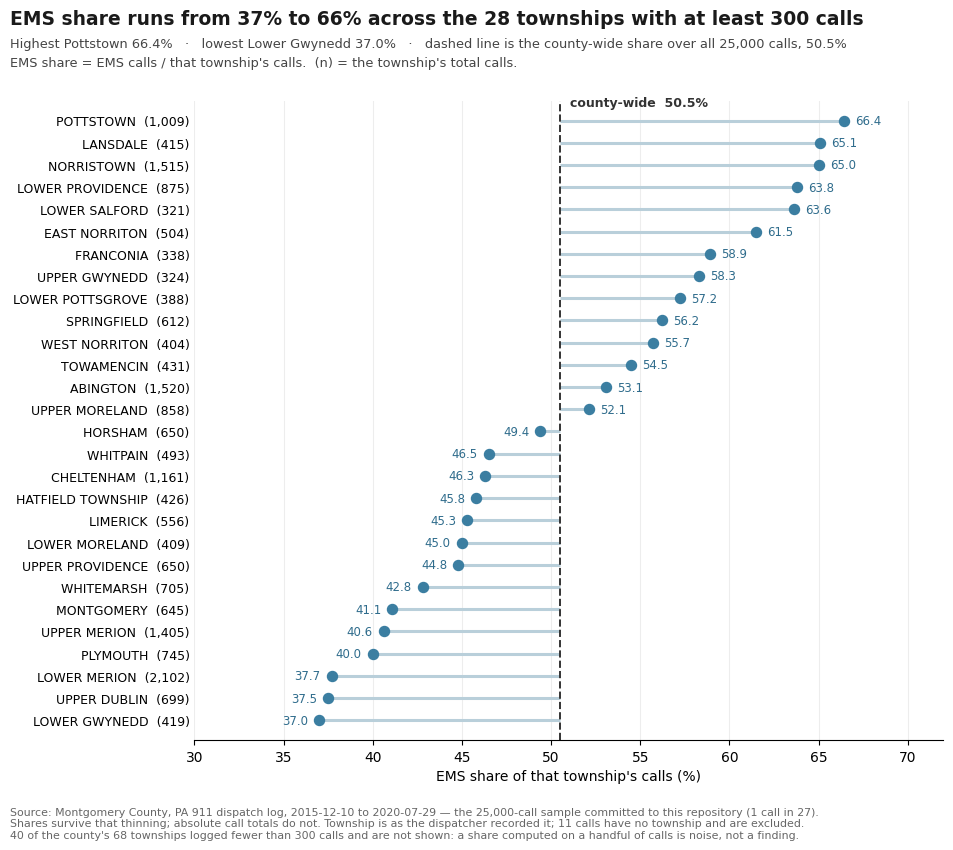

In [18]:
import matplotlib.pyplot as plt

MIN_CALLS = 300

county = float(report(measures=("ems_share_pct",)).iloc[0, 0])
d = report(by=("township",), measures=("calls", "ems_share_pct"),
           where="f.twp_key IS NOT NULL",
           having=f"COUNT(*) >= {MIN_CALLS}", order="ems_share_pct ASC")
top, bottom = d.iloc[-1], d.iloc[0]
n_hidden = q("SELECT COUNT(*) AS n FROM dim_township").iloc[0, 0] - len(d)

fig, ax = plt.subplots(figsize=(9.6, 8.4))
rows = range(len(d))
ax.hlines(rows, county, d["ems_share_pct"], color="#B9CFDA", lw=2.2, zorder=1)
ax.scatter(d["ems_share_pct"], rows, s=52, color="#3B7EA1", zorder=3)
ax.axvline(county, color="#333333", lw=1.4, ls="--", zorder=2)

ax.set_yticks(list(rows))
ax.set_yticklabels([f"{name}  ({n:,})" for name, n in zip(d["township"], d["calls"])], fontsize=9)
for i, v in zip(rows, d["ems_share_pct"]):
    # each label sits on the far side of its own dot, so it never lands on the reference line
    ax.annotate(f"{v:.1f}", (v, i), xytext=(8 if v >= county else -8, 0),
                textcoords="offset points", va="center",
                ha="left" if v >= county else "right", fontsize=8.5, color="#2F6C8C")
ax.annotate(f"county-wide  {county:.1f}%", (county, len(d) - 0.35), xytext=(7, 0),
            textcoords="offset points", fontsize=9, color="#333333", weight="bold")

ax.set_xlim(30, 72)
ax.set_ylim(-0.9, len(d) - 0.1)
ax.set_xlabel("EMS share of that township's calls (%)")
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", color="#EDEDED", zorder=0)
ax.set_axisbelow(True)

# Every string below is built from the rows just drawn, so the caption cannot contradict the chart.
fig.text(0.012, 0.980,
         f"EMS share runs from {bottom['ems_share_pct']:.0f}% to {top['ems_share_pct']:.0f}% "
         f"across the {len(d)} townships with at least {MIN_CALLS} calls",
         fontsize=13.5, weight="bold", color="#1A1A1A")
fig.text(0.012, 0.953,
         f"Highest {top['township'].title()} {top['ems_share_pct']:.1f}%   ·   "
         f"lowest {bottom['township'].title()} {bottom['ems_share_pct']:.1f}%   ·   "
         f"dashed line is the county-wide share over all {int(report(measures=('calls',)).iloc[0, 0]):,} calls, "
         f"{county:.1f}%",
         fontsize=9.3, color="#444444")
fig.text(0.012, 0.930,
         "EMS share = EMS calls / that township's calls.  (n) = the township's total calls.",
         fontsize=9.3, color="#444444")
fig.text(0.012, 0.011,
         "Source: Montgomery County, PA 911 dispatch log, 2015-12-10 to 2020-07-29 — the 25,000-call sample committed to this repository (1 call in 27).\n"
         "Shares survive that thinning; absolute call totals do not. Township is as the dispatcher recorded it; 11 calls have no township and are excluded.\n"
         f"{n_hidden} of the county's 68 townships logged fewer than {MIN_CALLS} calls and are not shown: a share computed on a handful of calls is noise, not a finding.",
         fontsize=7.9, color="#666666")

fig.tight_layout(rect=(0, 0.058, 1, 0.912))
plt.show()

In [19]:
display(report(by=("township",), measures=("calls", "ems_calls", "ems_share_pct"),
               where="w.twp_name IN ('POTTSTOWN', 'LOWER MERION')", order="calls DESC"))

above = int((d["ems_share_pct"] > county).sum())
print(f"{above} of the {len(d)} townships drawn sit above the county line, {len(d) - above} below.")

,township,calls,ems_calls,ems_share_pct
0,LOWER MERION,2102,792,37.7
1,POTTSTOWN,1009,670,66.4


14 of the 28 townships drawn sit above the county line, 14 below.


### Read it back

The test of a chart is not whether it looks good. It is what a stranger can correctly take from it,
and what they cannot.

**A reader who was not in the room can say:**

- `POTTSTOWN` (**66.4%**, 1,009 calls) has the highest medical share of any township with enough
  calls to judge; `LOWER GWYNEDD` (**37.0%**, 419 calls) the lowest.
- The spread is **wide** — nearly two to one — and it is **not** driven by size: `LOWER MERION`,
  the busiest township in the county at 2,102 calls, sits near the bottom at 37.7%.
- Fourteen townships are above the county line and fourteen below, so the county figure is a real
  midpoint here and not an average dragged by one outlier.

**The same reader must not say:**

- *"Pottstown has more medical emergencies."* It has a higher **share**. Pottstown logged 1,009
  calls; Lower Merion logged 2,102, and the cell above the read-back shows what its 37.7% is in
  calls: **792 EMS calls against Pottstown's 670**. A share and a count answer different
  questions, and this chart shows only one of them.
- *"Pottstown is sicker."* The chart shows how calls were **categorised by a dispatcher**, which
  is a mix of how people are, what the township's roads look like, and how that dispatch centre
  writes things down. Lesson 01 found `BUILDING FIRE` calls filed under `EMS`; the categorisation
  is a judgement, not a measurement.
- *"These are the county's medical hotspots."* 40 townships are missing from this picture, and
  the chart says so, in the smallest type on it — which is exactly where a reader in a hurry will
  not look. If the omission matters more than the ranking, the omission belongs in the title.

---

## Part 6 — Your turn

Four checked exercises and one with no checker. The model is built; use it. `check()` will tell
you whether you are right and will not tell you the answer.

### Exercise 1 — an attribute that only a dimension can give you

`dim_township.n_zips` counts the distinct ZIP codes seen for a township. It is a property of the
township, so it was computed once, in the dimension.

Return every township with **`n_zips` of 8 or more**, three columns in this order: `twp_name`,
`n_zips`, `calls` (that township's calls, from `fact_call`). Most ZIPs first, and where two
townships tie, alphabetically by name.

Look at what comes back before you move on. Two of the rows are not townships at all.

In [20]:
sql = """
-- your query here
"""
check("E1", sql)

E1: nothing to check yet — write your query above and re-run this cell.


### Exercise 2 — prove the dimension key

Part 2 claimed `call_type` alone is not a valid key. Prove it **from `dim_call_type` itself**,
with no reference to `calls`.

Two columns in this order: `call_type`, `categories` (how many rows of `dim_call_type` share that
call type). Only the ones with more than one. Alphabetical.

This is the query you should run against **every** dimension somebody hands you, before you trust
a single number that came out of it.

In [21]:
sql = """
-- your query here
"""
check("E2", sql)

E2: nothing to check yet — write your query above and re-run this cell.


### Exercise 3 — a question at a different grain

> **The fire chief:** "On what fraction of days did we get at least one `BUILDING FIRE` call?"

Read that carefully. Every measure in `MEASURES` counts **calls**; this one counts **days**. The
fact table's grain is one call, so no amount of `by=` will produce this — you have to write it.

**One row, one column** named `pct_of_days`: the number of distinct days with at least one
`BUILDING FIRE` call, as a percentage of **all days in `dim_date`**, rounded to **1** decimal.

When you have the number, notice what you have just discovered about the semantic model: a
question that sits one word away from the ones it answers, and it cannot answer it.

In [22]:
sql = """
-- your query here
"""
check("E3", sql)

E3: nothing to check yet — write your query above and re-run this cell.


### Exercise 4 — add a measure and use it

Add `traffic_share_pct` to `MEASURES` — the percentage of calls in the `Traffic` category, one
decimal place — and produce a report **by `part_of_week`** with columns `part_of_week`, `calls`,
`traffic_share_pct`, in alphabetical order of `part_of_week` (weekday, then weekend). 2 rows.

Then say to yourself, out loud, why the weekend number is lower. The model will not tell you; it
never does. That is the sentence the job pays for.

In [23]:
# MEASURES["traffic_share_pct"] = "..."       <- your measure here

answer = None                                 # <- your report(...) call here
check("E4", answer)

E4: nothing to check yet — write your answer above and re-run this cell.


### Exercise 5 — no checker, and that is the point

The Riyadh posting behind this folder asks for something no `check()` can grade:

> *"Ability to scope a vague business question into something answerable, and to say clearly when
> the data can't answer it."*

**The county director asks: "Which townships are we underserving?"**

Write your answer in the cell below, in four parts:

1. **The metric definition card** for the one metric you would publish to answer it — every row
   of the table in Part 4: name, grain, numerator, denominator, filter, floor, exclusions, source,
   owner. Invent nothing: build it only from columns that exist in this star schema.
2. **The `report(...)` call** you would run, written out.
3. **Three things your answer cannot say**, each tied either to a column that is **not** in this
   model or to something you saw break in this notebook. "Underserving" is doing a lot of work in
   that question — start there.
4. **One sentence you would say to the director**, in the meeting, that is both honest and useful.

In [24]:
answer = """
1.
2.
3.
4.
"""
print(answer)


1.
2.
3.
4.



---

## 💬 Discuss

Argue about these in pairs. None of them has one right answer.

1. **Three numbers, one name.** Part 1 produced 50.452%, 51.9685% and 51.105% for "EMS share", all
   correct. Your director's slide from last quarter says 52.0 and your model says 50.5. You have
   ten minutes before the meeting. What do you say, in what order, and what do you do afterwards
   so that it does not happen again? Now the harder half: who should have been allowed to decide
   which definition was "the" one, and when?

2. **Where should the 300-call floor live?** It is currently in the `HAVING` of one view. It could
   instead live in the model, so no report can escape it; in the chart, so only the picture applies
   it; or in the analyst's head. Pick one. What breaks in each of the other two the day someone
   genuinely needs a 40-call township?

3. **Self-serve or on request.** For a 20-person company, and again for a 2,000-person one: do you
   build the model and teach people to slice it, or keep every number passing through you? Give the
   failure mode of your choice, not just its benefit. Does your answer change if you are the only
   analyst and you want a holiday?

4. **The 11 calls with no township.** The `LEFT JOIN` keeps them, so every report sliced by
   township carries a row with a blank name. Show it, bucket it as `UNKNOWN`, or drop it? Which
   choice is most likely to be quietly wrong a year from now, when someone else has inherited the
   model and forgotten this conversation?

5. **The star cost you the seconds.** `fact_call` has the date and the hour; the minute and second
   are gone. That was a deliberate choice for a faster, smaller model. Who should have signed that
   off — the analyst who built it, the chief who might one day want response intervals, or nobody
   because it is reversible? What would you have had to write down at the time so that the person
   who hits the wall in 2028 knows it was a decision and not an accident?

---

## Part 7 — Power BI and PL-300, honestly

You have now built, in SQL, most of what a Power BI *model* is. It is worth saying plainly what
the tool adds, what the certificate is, and what it costs — because employers in that market pass
asked for it by name, and one of them, **Elm Company**, named it by its exam number.

**What you can and cannot do on your own machine.** Power BI **Desktop** is a Windows application.
There is no macOS or Linux build, and it cannot run inside a Jupyter notebook. If you are on a Mac
or a Chromebook your options are the browser-based Power BI service, a Windows virtual machine, or
a lab PC. This is the reason this notebook taught the model instead of the tool: a lesson half the
class cannot run is not a lesson.

**What transfers from this notebook, unchanged:**

| what you built here | what it is called in Power BI |
|---|---|
| `dim_township`, `dim_call_type`, `dim_date` | dimension tables |
| `fact_call` | the fact table |
| the `ON w.twp_key = f.twp_key` joins | relationships, with a cardinality and a filter direction |
| the `MEASURES` registry | measures, written in DAX |
| `pct_ems` stored in `township_report` | a calculated column — and the same trap |
| `v_ems_share_by_township` | a certified semantic model |
| "one row of `fact_call` is one dispatched call" | the grain, and it is still the first sentence |

**What does not transfer, and you have not learned it here:** Power Query (the loading and
cleaning layer), DAX itself — particularly `CALCULATE` and filter context, which is genuinely
unlike SQL and is where most people lose a week — row-level security, refresh schedules,
gateways, and workspace administration.

**The certificate.** Exam **PL-300** leads to *Microsoft Certified: Power BI Data Analyst
Associate*. Everything in this section was read off Microsoft's own pages and the Pearson VUE
price list in the session this notebook was written; check them again before you pay for anything,
because Microsoft revises exams and prices.

- **Level:** Intermediate. **Renewal:** every 12 months, by a **free** online assessment on
  Microsoft Learn — the certificate expires if you do not.
- **Length:** *"You will have 100 minutes to complete this assessment."* Proctored, with
  interactive components. **Pass mark: 700** out of 1000.
- **Retake:** allowed 24 hours after a first failure; longer waits after that.
- **Skills measured, as of 20 April 2026:** Prepare the data **25–30%**, Model the data
  **25–30%**, Visualize and analyze the data **25–30%**, Manage and secure Power BI **15–20%**.
- **Price in Saudi Arabia: 83 USD** for the commercial rate, **46 USD** for the academic rate,
  against **165 USD** in the United States. Those come from Pearson VUE's *Microsoft pricing by
  country* list dated 1 November 2024; Microsoft's own exam page prints no number at all, saying
  only *"Price based on the country or region in which the exam is proctored."* **Confirm the
  price at checkout, not from a blog.**
- **Language:** the exam is offered in English, Japanese, Chinese (Simplified), Korean, German,
  French, Spanish, Portuguese (Brazil), Chinese (Traditional) and Italian. **Arabic is not on that
  list.** Microsoft's study guide adds: *"If the exam isn't available in your preferred language,
  you can request an additional 30 minutes to complete the exam."* If you sit it in English as a
  second language, **ask for that 30 minutes.** It is a stated entitlement, not a favour.

**How much of PL-300 did this notebook actually touch?** Honestly: a slice of one of the four
areas. Under *Prepare the data*, the study guide lists "Create fact tables and dimension tables"
and "Identify and create appropriate keys for relationships" — that was Part 2. Under *Model the
data*: "Create single aggregation measures", "Identify use cases for calculated columns and
calculated tables", "Create a common date table", "Improve performance by reducing granularity" —
Parts 1 to 4. Under *Visualize*: "Select an appropriate visual", "Use reference lines" — Part 5.
That is perhaps a fifth of the exam, and none of it in the tool the exam tests you in. **Two hours
of SQL is not exam preparation.** It is the part of the exam that is still true when you change
employer and the new place uses Tableau, or Looker, or a Python notebook.

**One thing to argue about:** the exam costs 83 USD and covers a tool you may not be able to
install. Is it the right first certificate for a graduate of this programme, or would the same
money and the same three weeks be better spent on something a Saudi employer can verify by giving
you a laptop and a question? Take a side.

---

## ⚠️ Where this breaks

**1. The model threw away the minute and the second, and that door only opens one way.**
`calls.ts` has the time to the second. `fact_call` has a date and an hour. That was a real
decision — "Improve performance by reducing granularity" is a PL-300 bullet — and it has a price
that nobody notices until somebody asks a question at the finer grain.

In [25]:
display(q("""
SELECT CAST(substr(ts, 15, 2) AS INTEGER) / 15  AS quarter_of_the_hour,
       COUNT(*)                                 AS calls,
       ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM calls), 1) AS pct
FROM calls
GROUP BY quarter_of_the_hour
ORDER BY quarter_of_the_hour
"""))

,quarter_of_the_hour,calls,pct
0,0,6386,25.5
1,1,6090,24.4
2,2,6205,24.8
3,3,6319,25.3


Answerable on the flat table: calls are spread evenly across the four quarters of the hour —
**25.5 / 24.4 / 24.8 / 25.3 per cent** — so there is no shift-change or rounding artefact in how
this county timestamps its calls, which is a genuinely useful thing to have checked.

The same question against the star:

In [26]:
q("SELECT f.call_id, f.ts FROM fact_call f LIMIT 3")

DatabaseError: Execution failed on sql 'SELECT f.call_id, f.ts FROM fact_call f LIMIT 3': no such column: f.ts

`no such column: f.ts`. Not a wrong answer — no answer. **Write down what a model cannot answer on
the day you build it**, because the person who needs it in three years will assume the omission
was an accident and go looking for a bug.

**2. Measures are not all additive, and your tool will not warn you.** `calls` can be added across
any dimension. `ems_share_pct` cannot be added across anything at all — and it is a number in a
numeric column, so every BI tool on earth will happily offer to total it.

In [27]:
by_twp = report(by=("township",), measures=("calls", "ems_share_pct"),
                where="f.twp_key IS NOT NULL", having="COUNT(*) >= 300")

print(f"sum of the {len(by_twp)} townships' calls          : {by_twp['calls'].sum():,}"
      f"   (the model's own total: {int(report(measures=('calls',)).iloc[0, 0]):,})")
print(f"sum of the {len(by_twp)} townships' ems_share_pct  : {by_twp['ems_share_pct'].sum():,.1f}")
print(f"mean of the {len(by_twp)} townships' ems_share_pct : {by_twp['ems_share_pct'].mean():.4f}"
      f"   (the model's own share: {report(measures=('ems_share_pct',)).iloc[0, 0]})")

sum of the 28 townships' calls          : 20,579   (the model's own total: 25,000)
sum of the 28 townships' ems_share_pct  : 1,431.2
mean of the 28 townships' ems_share_pct : 51.1143   (the model's own share: 50.5)


The `calls` column sums to 20,579, which is less than 25,000 because 40 townships and 11
township-less calls were filtered out — a total that is *smaller* than the whole, and explainable.
The share column sums to **1,431.2**, a number with no meaning of any kind, and averages to
**51.1143** against the model's **50.5**. Neither of the last two raised anything.

There is standard vocabulary for this: `calls` is **fully additive**, a running balance is
**semi-additive** (you add it across products but not across time), and a ratio is
**non-additive**. Mark every measure in your registry with which one it is, and put the
non-additive ones somewhere a total button cannot reach.

**3. Nothing enforces the keys.** `CREATE TABLE ... AS SELECT` copies data, not constraints. There
are no foreign keys in this database, so a fact row can point at a dimension row that does not
exist, and the `JOIN` in `FROM` will simply drop it.

In [28]:
con.execute("""
INSERT INTO fact_call (call_id, date_key, hour, twp_key, type_key, addr)
VALUES (999999, '2018-05-01', 9, 1, 9999, 'A CALL THAT POINTS AT NOTHING')
""")

print("rows physically in fact_call :", q("SELECT COUNT(*) AS n FROM fact_call").iloc[0, 0])
print("rows the model reports       :", int(report(measures=("calls",)).iloc[0, 0]))

con.execute("DELETE FROM fact_call WHERE call_id = 999999")
print("cleaned up, back to           :", q("SELECT COUNT(*) AS n FROM fact_call").iloc[0, 0])

rows physically in fact_call : 25001
rows the model reports       : 25000
cleaned up, back to           : 25000


**25,001 rows in the table, 25,000 in every report.** The call vanished silently, because the
inner join to `dim_call_type` had nothing to match. In a real warehouse you declare foreign keys
and the database refuses the bad row; in SQLite you must switch them on per connection
(`PRAGMA foreign_keys = ON`) *and* declare them in the `CREATE TABLE`, which `CREATE TABLE AS
SELECT` cannot do. Until then, the check is yours to run: **does the fact's row count equal the
model's `calls`?** If not, a join is eating rows.

**4. `dim_date` is built from the fact, and got away with it.** 1,694 rows for a 1,694-day span,
so nothing is missing — this time. Build a date dimension the same way on data with a quiet week
and that week does not exist: it is not a zero on your chart, it is absent, and `AVG` divides by a
denominator that already excluded it.

**5. Per-call ZIP is gone.** The flat table has a `zip` on every call. The star has `main_zip` and
`n_zips` on the *township*, which is a different fact about a different thing — and lesson 01
measured that 3,025 of these calls (12.1%) have no ZIP at all. Lesson 02's join from calls to ZIP areas cannot be reproduced from this star.
Every model is a decision about what you will not be able to ask.

**6. One fact table is the easy case.** Real models have several at different grains — calls, and
staffing hours, and budget by month — and the hard part is a question that touches two of them at
once. Nothing in this notebook prepares you for that.

**7. Everything here is the 1-in-27 sample.** "Pottstown is 66.4% medical" survives the thinning.
"Pottstown logged 1,009 calls" does not; the real figure is roughly 27 times larger. Say which of
the two you are quoting, every time.

**8. This is not Power BI, and a chart is not a dashboard.** You built one figure with matplotlib.
A dashboard is several, laid out together, with filters that interact, refreshing on a schedule,
on a page other people can find. None of that is here. What is here is the part that decides
whether the dashboard is right.

## The card to keep

| you want | you do | the trap |
|---|---|---|
| a table anyone can trust | write the **grain** first: "one row is one ___" | if you cannot say it, the model is not ready |
| a dimension | one row per real thing, wide, few rows | key must be unique **and** determine every attribute |
| a fact table | keys + measures, thin, many rows | check the row count did not move after the build |
| a percentage | write it as a **measure**, evaluated at query time | a stored share cannot be averaged back into a share |
| a metric | name + numerator + **denominator** + filter + floor | publish the name alone and you published nothing |
| one definition for everyone | a view, or a registry entry, with an owner | a view cannot stop anyone averaging its output |
| joins that keep every fact row | `LEFT JOIN` from fact to dimension | `INNER JOIN` deletes rows and says nothing |
| to know a join is safe | `COUNT(*)` before vs after | fan-out is silent; lesson 02 measured it |
| a chart a stranger can read | finding in the title, `n` on the labels, caveats on the image | a hand-typed title is a fact with no test |
| a comparison | draw the reference line | a share alone is unreadable |
| to total a ratio | **do not** | fully additive, semi-additive, non-additive: mark which |

---

**Sources used in this notebook**, all fetched in the session it was written:

- Microsoft Learn, *Microsoft Certified: Power BI Data Analyst Associate* —
  `learn.microsoft.com/credentials/certifications/data-analyst-associate/` — exam length, renewal
  frequency, languages, retake policy, and the sentence that no price is printed.
- Microsoft Learn, *Study guide for Exam PL-300* —
  `learn.microsoft.com/credentials/certifications/resources/study-guides/pl-300` — skills measured
  as of 20 April 2026 with their weightings, the pass mark of 700, and the extra-30-minutes
  entitlement for a non-native language.
- Pearson VUE, *Microsoft pricing by country*, dated 1 November 2024, linked from
  `pearsonvue.com/us/en/microsoft/vouchers.html` — Saudi Arabia 83 USD commercial / 46 USD
  academic for role-based exams, against 165 USD in the United States.
- SQL lessons 01–03 in this folder, for the flat table, the `LIKE`/`NULL`/fan-out results this
  lesson builds on, and the market evidence recorded in `SQL/README.md`.